# Step 13: 2-D Cavity Flow with Navier-Stokes equation

In this notebook I try to simulate the evolution of a compressible Newtonian fluid with constant viscosity inside a 2-D cavity. The theory is split as follows:
- **the search for more familiar equations**: I re-write tha mass continuity and Navier-Stokes equations in a more tractable way, useful for the discretization of the problem, as I have already dealt with the Poisson equation in "Step 12" (heavy math coming!);
- **discretization**: I discretize each of the three equations and discuss the numerical validity of $\vec{v}\, (\vec{x}, t)$ as a solenoidal field. Then, I introduce the computational steps needed;
- **differencing schemes**: different kind of schemes can be used in Finite Difference simulations. Specifically for the convective terms, I introduce the upwind differencing scheme, which is more powerful than a simple bacward scheme, because, in cases of high Reynolds number, greater negative velocities are present;
- **initial and boundary conditions**: I illustrate the initial and boundary conditions used in the simulation and how they are implemented in a discrete fashion;
- **benchmarking analysis**: I compare the results of my own simulation with the high fidelity simulation done in the 1982's paper by Ghia et al.

## The search for more familiar equations

The mass continuity equation reads $$\frac{\partial \rho}{\partial t} + \nabla \cdot \left(\rho\, \vec{v}\right) = 0$$ which for incompressible fluid flows (i.e. $\rho\left(\vec{x}, t\right) = \rho$) reduces to the following
$$0 + \rho \left(\nabla \cdot \vec{v}\right) = 0$$
$$\nabla \cdot \vec{v}= 0$$

Thus the motion of an incompressible Newtonian fluid with constant viscosity is regulated by the system of these four equations:

$$(1)\,\,\,\, 
\left\{ \begin{array}{l} 
    \nabla \cdot \vec{v} = 0 \\ 
    \frac{D\vec{v}}{Dt} = \frac{\partial \vec{v}}{\partial t} + (\vec{v} \cdot \nabla)\, \vec{v} = - \frac{1}{\rho}\, \vec{\nabla}p + \nu\, \nabla^2 \vec{v} 
\end{array}\right. \,$$

where only the velocity $\vec{v}\, (\vec{x}, t)$ and pressure $p\, (\vec{x}, t)$ fields are to be calculated, given suitable boundary and initial conditions. The latters can be usefully simplified if we compute the divergence of the momentum conservation equation, which is then treated in cartesian coordinates for simplicity:

$$LHS = \nabla \cdot \left(\frac{\partial \vec{v}}{\partial t} + (\vec{v} \cdot \nabla)\, \vec{v}\right) = \frac{\partial (\nabla \cdot \vec{v})}{\partial t} + \nabla \cdot \left[(\vec{v} \cdot \nabla)\, \vec{v}\right] = \nabla \cdot \left[(\vec{v} \cdot \nabla)\, \vec{v}\right]$$

Remembering that 

$$\nabla \cdot (f\, \vec{A}) = f\, (\nabla \cdot \vec{A}) + \vec{A} \cdot \vec{\nabla} f$$

It yields the following (where I partially use the Einstein shorthand notation):

$$\nabla \cdot \left[(\vec{v} \cdot \nabla)\, \vec{v}\right] = \nabla \cdot \left(u_i\, \frac{\partial \vec{v}}{\partial x_i}\right) = u_i\left(\nabla \cdot \frac{\partial \vec{v}}{\partial x_i}\right) + \frac{\partial \vec{v}}{\partial x_i} \cdot \vec{\nabla}u_i = \frac{\partial u_j}{\partial x_i} \frac{\partial u_i}{\partial x_j}$$

Because, under the assumption of the validity of [Schwarz's theorem's](https://en.wikipedia.org/wiki/Symmetry_of_second_derivatives#:~:text=%5B7%5D-,Schwarz%27s%20theorem,-%5Bedit%5D) hypothesis, we have that

$$u_i\left(\nabla \cdot \frac{\partial \vec{v}}{\partial x_i}\right) = u_i\left(\frac{\partial}{\partial x_j} \frac{\partial u_j}{\partial x_i}\right) = u_i\left(\frac{\partial}{\partial x_i} \frac{\partial u_j}{\partial x_j}\right) = u_i\, \frac{\partial}{\partial x_i} (\nabla \cdot \vec{v}) = (\vec{v} \cdot \nabla)(\nabla \cdot \vec{v}) = 0$$

While, on the right hand side, the divergence gives

$$RHS = - \frac{1}{\rho}\, \nabla^2p + \nu\, \left[\nabla \cdot (\nabla^2 \vec{v})\right]$$

But the laplacian of a divergence is the divergence of the laplacian, that is

$$\nabla \cdot (\nabla^2 \vec{v}) = \frac{\partial}{\partial x_i} \left( \frac{\partial^2 u_i}{\partial x^2} + \frac{\partial^2 u_i}{\partial y^2} + \frac{\partial^2 u_i}{\partial z^2} \right) = \frac{\partial^2}{\partial x^2} \left( \nabla \cdot \vec{v} \right) + \frac{\partial^2}{\partial y^2} \left( \nabla \cdot \vec{v} \right) + \frac{\partial^2}{\partial z^2} \left( \nabla \cdot \vec{v} \right) = \nabla^2 (\nabla \cdot \vec{v}) = 0$$

Thus the divergence applied on the Navier-Stokes equations reduces to:

$$\left( \frac{\partial u}{\partial x} \right)^2 + \left( \frac{\partial v}{\partial y} \right)^2 + \left( \frac{\partial w}{\partial z} \right)^2 + 2 \frac{\partial u}{\partial y}\frac{\partial v}{\partial x} + 2 \frac{\partial u}{\partial z}\frac{\partial w}{\partial x} + 2 \frac{\partial v}{\partial z}\frac{\partial w}{\partial y} = - \frac{1}{\rho} \nabla^2 p$$

And the system $(1)$ is mathematically equivalent to the next one, where the mass continuity equation is replaced by a more familiar Poisson equation for the pressure field, where the source term $b (\vec{x}, t)$ is now linked, through differentiation, to the velocity field:

$$(2)\,\,\,\, 
\left\{ \begin{array}{l} 
    \nabla^2 p = b (\vec{x}, t) = - \rho \left( \frac{\partial u_i}{\partial x_j}\frac{\partial u_j}{\partial x_i} \right) \\
    \frac{D\vec{v}}{Dt} = \frac{\partial \vec{v}}{\partial t} + (\vec{v} \cdot \nabla)\, \vec{v} = - \frac{1}{\rho}\, \vec{\nabla}p + \nu\, \nabla^2 \vec{v}
\end{array}\right. \,$$

**HINT**: if some math is still unclear, I suggest to write extensively all the summations and see how the terms can be re-arranged.

## Discretization

In the last paragraph we found that an incompressible Newtonian flow with constant viscosity in a *continuous medium* is described by the following system:

$$(2)\,\,\,\, 
\left\{ \begin{array}{l} 
    \nabla^2 p = b (\vec{x}, t) = - \rho \left( \frac{\partial u_i}{\partial x_j}\frac{\partial u_j}{\partial x_i} \right) \\
    \frac{D\vec{v}}{Dt} = \frac{\partial \vec{v}}{\partial t} + (\vec{v} \cdot \nabla)\, \vec{v} = - \frac{1}{\rho}\, \vec{\nabla}p + \nu\, \nabla^2 \vec{v}
\end{array}\right. \,$$

Now, practically speaking, we have to decide the solution procedure; that is, in what order we are going to compute things. But first, we have to remember that we are not working anymore in a continuous medium, but in a discretized one instead! 

The scope of every simulation is the emulation of, an apparently, continuous reality (i.e. a reality modeled with continuous equations, that use the tools of calculus!). Thus, we are trying to force a solution, given by discrete operations in a discrete world, to be similar as possible to a *real* (read *continuous*) solution. This procedure is not straightforward and uses some really neat and strange tricks, in order to neutralize the equally neat and strange issues born by the simulations (unphysical issues such as: numerical instability, numerical and computational errors, numerical diffusion, ... see "Kawata - Computational Plasma Science" section 1.7 for more of these).

So, the solution procedure is the following (as illustrated [here for Dr. Gan](https://drzgan.github.io/Python_CFD/15.%20Cavity%20flow%20with%20Naiver-Stokes%20equation.html) and [here for Prof. Barba](https://barbagroup.github.io/essential_skills_RRC/numba/4/#solution-procedure)):
1. set up an initial velocity field
2. compute the pressure field to some degree of accuracy (i.e. until it reaches a quasi-steady state) solving iteratively the Poisson equation for timestep ```n``` (if an initial condition for pressure is not already presented, coherently, with the initial velocity field)
3. solve for the velocity field at timestep ```n + 1``` knowing the quasi-steady pressure field
4. repeate

But is the starting velocity field satisfying the solenoidal condition? That is, is the discretized version of ($\nabla \cdot \vec{v}$) equal to 0? It may be not! It may depend on the adopted differencing scheme or on the used mesh grid, and subsequently also the future time configurations can be non-solenoidal. Thus the pressure Poisson equation, simplified in the last section, **cannot be used** because in our discrete world of simulation the mass continuity equation does not give $(\nabla \cdot \vec{v}) = 0$ necessarily!

It may seem odd, and it is, but it does make some sense, at least heuristically! For more about this, start from here:
- [barbagroup post](https://lorenabarba.com/blog/cfd-python-12-steps-to-navier-stokes/#comment-1405089241)
- [stack exchange post](https://math.stackexchange.com/questions/2211539/navier-stokes-equation-about-pressure#:~:text=From%20a%20physical%20point%20of%20view%20this%20feels%20odd.%20What%20is%20it%20that%20obliges%20the%20pressure%20to%20behave%20in%20this%20way%3F)

A smart (is it?) trick to get rid of this situation is to use the original system $(1)$, proposed at the beginning of this notebook, and use the complete, non-simplified version of the divergence of the momentum equation for the calculations. That's because, in this way, we are not imposing the solenoidal property of the velocity field. 

The proposed solution by Prof. Barba and Dr. Gan is to use a modified version of the pressure Poisson equation, which magically leads to a correct description of the continuous reality and consists in keeping the time derivative, even though in a *continuos medium* it can be further simplified...

$$\nabla^2 p = \rho \left[ \frac{\partial}{\partial t} (\nabla \cdot \vec{v}) - \frac{\partial u_i}{\partial x_j} \frac{\partial u_j}{\partial x_i} \right]$$

In this way, our system $(2)$ in 2D becomes:

$$\frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial y^2} = \rho \left[ \frac{\partial}{\partial t} \left( \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} \right) - \left(\frac{\partial u}{\partial x}\right)^2 - \left(\frac{\partial v}{\partial y}\right)^2 - 2\,\frac{\partial u}{\partial y}\frac{\partial v}{\partial x} \right]$$
$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = - \frac{1}{\rho} \frac{\partial p}{\partial x} + \nu\left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$$
$$\frac{\partial v}{\partial t} + u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y} = - \frac{1}{\rho} \frac{\partial p}{\partial y} + \nu\left( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \right)$$

## Differencing schemes

The system illustrated above is then discretized using these differencing schemes. In case we are not using the *upwind* scheme for the convective terms, we have:
- **forward**: time derivatives,
- **backward**: 1st order space derivatives of $u$ and $v$,
- **central**: 2nd order space derivatives of $u$ and $v$, and 1st order space derivative of pressure.

**ATTENTION**: an exception is made for the pressure Poisson equation, where all space derivatives are discretized using a **central scheme**. Remember that we are using a **5-point stencil method** for its evalutation, thus it is logical to use this scheme also for other 1st order space derivatives.

Isolating the terms of interested we obtain:

$$u_{i,\, j}^{n+1} = u_{i,\, j}^n - u_{i,\, j}^n \frac{\Delta t}{\Delta x} \left(CONVECTION(u, x)\right) - v_{i,\, j}^n \frac{\Delta t}{\Delta y} \left(CONVECTION(u, y)\right) - 
\frac{\Delta t}{2 \rho \Delta x} \left(p_{i+1,\, j}^n - p_{i-1,\, j}^n\right) + 
\nu\Delta t \left(\frac{u_{i+1,\, j}^n - 2u_{i,\, j}^n + u_{i-1,\, j}^n}{\Delta x^2} + \frac{u_{i,\, j+1}^n -2u_{i,\, j}^n + u_{i,\, j-1}^n}{\Delta y^2}\right)$$

$$v_{i,\, j}^{n+1} = v_{i,\, j}^n - u_{i,\, j}^n \frac{\Delta t}{\Delta x} \left(CONVECTION(v, x)\right) - v_{i,\, j}^n \frac{\Delta t}{\Delta y} \left(CONVECTION(v, y)\right) - 
\frac{\Delta t}{2 \rho \Delta y} \left(p_{i+1,\, j}^n - p_{i-1,\, j}^n\right) + 
\nu\Delta t \left(\frac{v_{i+1,\, j}^n - 2v_{i,\, j}^n + v_{i-1,\, j}^n}{\Delta x^2} + \frac{v_{i,\, j+1}^n -2v_{i,\, j}^n + v_{i,\, j-1}^n}{\Delta y^2}\right)$$

$$\begin{multline*}
p_{i,\, j}^n = \frac{\Delta x^2 \left(p_{i,\, j+1}^n - p_{i,\, j-1}^n\right) + \Delta y^2 \left(p_{i+1,\, j}^n - p_{i-1,\, j}^n\right)}{2\left( \Delta x^2 + \Delta y^2 \right)} \\
-\frac{\rho \Delta x^2 \Delta y^2}{2\left( \Delta x^2 + \Delta y^2 \right)} \times
\left[ \frac{1}{\Delta t} \left( \frac{u_{i+1,\, j}^n - u_{i-1,\, j}^n}{2\Delta x} + \frac{v_{i,\, j+1}^n - v_{i,\, j-1}^n}{2\Delta y} \right) -
2 \frac{u_{i,\, j+1}^n - u_{i,\, j-1}^n}{2\Delta y} \frac{v_{i+1,\, j}^n - v_{i-1,\, j}^n}{2\Delta x} - 
\left( \frac{u_{i+1,\, j}^n - u_{i-1,\, j}^n}{2\Delta x} \right)^2 - \left( \frac{v_{i,\, j+1}^n - v_{i,\, j-1}^n}{2\Delta y} \right)^2 \right]
\end{multline*}$$

Where $CONVECTION(u, x)$, means the convective term for $u$ with respect to $x$ axis; which can be written in different ways. 

In case a simple **BACKWARD** scheme is adopted, we have:

- $CONVECTION(u, x) = u_{i,\, j}^n - u_{i-1,\, j}^n\;\;\;\;-\;\;\;\;CONVECTION(u, y) = u_{i,\, j}^n - u_{i,\, j-1}^n$
- $CONVECTION(v, x) = v_{i,\, j}^n - v_{i-1,\, j}^n\;\;\;\;-\;\;\;\;CONVECTION(v, y) = v_{i,\, j}^n - v_{i,\, j-1}^n$

If the **UPWIND** scheme is adopted, then the former becomes:

- $CONVECTION(u, x) = u_{east}^n - u_{west}^n\;\;\;\;-\;\;\;\;CONVECTION(u, y) = u_{north}^n - u_{south}^n$
- $CONVECTION(v, x) = v_{east}^n - v_{west}^n\;\;\;\;-\;\;\;\;CONVECTION(v, y) = v_{north}^n - v_{south}^n$

Where we used the geographical terminology to underline the fact that, by definition, the [difference quotient](https://en.wikipedia.org/wiki/Difference_quotient) is defined by the upstream value (mount value) minus the downstream one (valley one) with respect to a choosen coordinate system. Thus, in our case we have:

- x-axis: (upstream = east)  -  (downstream = west)
- y-axis: (upstream = north)  -  (downstream = south)

And it is up to us to choose, for a grid point $(i,\, j)$, what combination is better:
- **BACKWARD**: (upstream = $(i,\, j)$ point)  -  (downstream = $(i-1,\, j)$ point) AND (upstream = $(i,\, j)$ point)  -  (downstream = $(i,\, j-1)$ point)
- **FORWARD**:(upstream = $(i+1,\, j)$ point)  -  (downstream = $(i,\, j)$ point) AND (upstream = $(i,\, j+1)$ point)  -  (downstream = $(i,\, j)$ point)

The upwind difference scheme consists in choosing:
- **BACKWARD** when the flow is **ALONG** the coordinate axis
- **FORWARD** when the flow is **AGAINST** the coordinate axis

## Initial and boundary conditions

We intend to simulate a 2D cavity flow, that is a flow produced by a lid slipping on the fluid surface. The cavity will be a square portion of $\mathbb{R}^2$ of length 2: $\left[0,\, 2\right] \times \left[0,\, 2\right]$.

Initially, the fluid is still ($u,\, v = 0$) and $p = 0$ everywhere.

After, the lid is slipping with a constant velocity, thus: $u = 1$ at $y = 2$ and $u,\, v = 0$ everywhere else on the boundary due to no-slip condition and physical barriers (i.e. the walls) of the system. 

While for the pressure field we have: $\frac{\partial p}{\partial y} (x,\, 0) = 0$, $p(x,\, 2) = 0$ and $\frac{\partial p}{\partial x} (0,\, y) = \frac{\partial p}{\partial x} (2,\, y) = 0$, which are discretized as: $$p_{i,\, 0} = p_{i,\, 1} \;\;\wedge\;\; p_{i,\, -1} = 0 \;\;\wedge\;\; p_{0,\, j} = p_{1,\, j} \;\;\wedge\;\; p_{-1,\, j} = p_{-2,\, j}$$

**N.B.**: the former can be adapted for a cavity of different size, just change 2 with any other positive value.

## Benchmarking analysis

For the benchmarking of my simulation, I use the 1982's results published by [Ghia et al](http://www.msaidi.ir/upload/Ghia1982.pdf), specifically I compare their values of $u = u\,(1.0, y)$ on page 398 with my own.

**WITHOUT upwind scheme**

When $Re = 100$, simulated data corresponds to Ghia's with a certain mesh size ($41\times41$ seems to work) and after enough iterations are made: $nt = 1000$ is not enough, while $nt = 5000$ seems to be. It also seems that different mesh sizes require different number of iterations to obtain a fully developed flow; in fact, a $81\times81$ grid needs  $nt = 12000$ for stabilization, but the results differe greatly from Ghia's. Thus, there's a *grid convergence* discussione to be made: somehow a $41\times41$ grid converges correctly, while a different one does not. I don't know the reasons, but as already noted in previous notebooks, at the moment it's a pretty obscure thing in which I prefer to not deep dive in.

Generally speaking, $Re = 100$ can be obtained also by doubling the ```length``` and the viscosity ```nu```, but clearly the values related to system's dynamic's change. Even if the dynamic itself rests, logically and reasonably, the same.

When $Re = 400$, the simulation crashes. Probably it's caused by the larger values of negative velocities present in the convection term. In Step 13.2, Dr. Gan suggests to solve it by implementing the *upwind differencig scheme* for the culprit term itself.

**WITH upwind scheme**

The code seems fine with $Re = 400$ and $Re = 800$. Higher Reynolds number were not investigated, instead different values of viscosity and lid velocity were tried to see how the dynamic changes. I couldn't make a succesful comparison with Ghia's results because I did not have the time to read through the entire paper to see how viscosisty $\nu$ and speed $c$ were defined. Thus, a proper comparison couldn't be done.

## Finally coding!

In [5]:
# Yes, Wong is finally coding!
import numpy as np
from matplotlib import pyplot as plt, cm
import time

In [147]:
# REMEMBER: we have defined u = np.array( (ny, nx) ), thus the first index is y-related and the second index is x-related

# -------------------------------------------------------- PRESSURE POISSON EQUATION

# Build up the source term 'b' of the PPE.
#   This term is not defined outside the simulation, but only inside of it.
#   Therefore, the definition of the 'b' array is made at the beginning of
#   the 'cavity_flow' function. In order to preserve the "black box" nature of it.
def build_up_b (b, rho, dt, dx, dy, un, vn):

    b[1:-1, 1:-1] = ( rho * ( ( (un[1:-1, 2:] - un[1:-1, 0:-2])/dx + (vn[2:, 1:-1] - vn[0:-2, 1:-1])/dy )/(2*dt) - 
                             2*((un[2:, 1:-1] - un[0:-2, 1:-1])*(vn[1:-1, 2:] - vn[1:-1, 0:-2])/(4*dx*dy)) -
                             ((un[1:-1, 2:] - un[1:-1, 0:-2])/(2*dx))**2 - 
                             ((vn[2:, 1:-1] - vn[0:-2, 1:-1])/(2*dy))**2 ) )
    
    return b
    
# Finite iterative solver:
#   We hope that in 'niter' iterations the pressure field reach a suitable steady state.
#   If you want to be sure to have reached a quasi-steady state, use an iterative solver.
#   See the function 'poisson2D' further down, which is taken from the Step 12's notebook.
def pressure_poisson (p, b, dx, dy):
    pk = np.zeros_like(p)

    for i in range(nit):   #Iterate 'niter' times: can be internally redefined
        pk = p.copy()
        p[1:-1, 1:-1] = ( (pk[1:-1, 2:] + pk[1:-1, 0:-2])*dy**2 + (pk[2:, 1:-1] + pk[0:-2, 1:-1])*dx**2 - b[1:-1, 1:-1]*(dx*dy)**2 ) / (2*(dx**2 + dy**2))

        #BCs:
        p[0, :] = p[1, :]     #dp/dy = 0 at y = 0
        p[-1, :] = 0             #p = 0 at y = 2
        p[:, 0] = p[:, 1]     #dp/dx = 0 at x = 0
        p[:, -1] = p[:, -2]   #dp/dx = 0 at x = 2

    return p

# Iterative solver:
#   'my_dist' compute the distance between two following iterations (a is after b).
#   It is used for the evalutaion of the PPE's solution convergence inside 'poisson2D' function.
#   The distance is essentially an l1norm of the vector (a-b) normalized to the norm of the vector b.
def my_dist (a, b):
    ny = np.size(a, axis=0)
    nx = np.size(a, axis=1)
    return np.sum(np.abs(a - b)) / (np.sum(np.abs(b)) + 1e-8)
    # return np.sum(np.abs(a) - np.abs(b)) / np.sum(np.abs(b))

#   Iterative solver with a target norm to reach (here called 'epsilon').
#   For the sake of security, the iteration will stop after 'max_iter' iterations.
#   In order to see if this happens, we return also the number of executed iterations 'iter'.
def poisson2D (p, b, dx, dy, epsilon = 1e-4, max_iter = 1e5):
    iter = 0
    dist = 1
    pk = np.zeros_like(p)

    while (dist > epsilon and iter <= max_iter):

        pk = p.copy()
        # Remember: 1st index regards y-axis, 2nd index the x-axis
        p[1:-1,1:-1] = ( (pk[2:, 1:-1] + pk[0:-2, 1:-1])*dx**2 + (pk[1:-1, 2:] + pk[1:-1, 0:-2])*dy**2 - b[1:-1, 1:-1]*(dx*dy)**2 ) / (2*(dx**2 + dy**2))

        #BCs:
        p[0, :] = p[1, :]     #dp/dy = 0 at y = 0
        p[-1, :] = 0             #p = 0 at y = 2
        p[:, 0] = p[:, 1]     #dp/dx = 0 at x = 0
        p[:, -1] = p[:, -2]   #dp/dx = 0 at x = 2
        
        # Escape terms
        dist = my_dist(p, pk)
        iter += 1

    return p, (iter, max_iter)

# -------------------------------------------------------- VELOCITY FIELD

# Convective derivative: BACKWARD scheme
#   Here, we discretize the convective term applying the backward differencing scheme, 
#   which is apt for positive, or little negative, velocity values.
#   For the implementation of the UPWIND scheme, see further down.

def velocity_u_update (u, un, vn, pn, dt, dx, dy, nu, rho):

    u[1:-1, 1:-1] = ( un[1:-1, 1:-1] -
                      un[1:-1, 1:-1]*(dt/dx)*(un[1:-1, 1:-1] - un[1:-1, 0:-2]) -
                      vn[1:-1, 1:-1]*(dt/dy)*(un[1:-1, 1:-1] - un[0:-2, 1:-1]) -
                      (pn[1:-1, 2:] - pn[1:-1, 0:-2])*dt/(2*rho*dx) +
                      nu*dt*( (un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, 0:-2])/dx**2 + (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[0:-2, 1:-1])/dy**2 ) )
    
    return u

def velocity_v_update (v, un, vn, pn, dt, dx, dy, nu, rho):

    v[1:-1, 1:-1] = ( vn[1:-1, 1:-1] -
                      un[1:-1, 1:-1]*(dt/dx)*(vn[1:-1, 1:-1] - vn[1:-1, 0:-2]) -
                      vn[1:-1, 1:-1]*(dt/dy)*(vn[1:-1, 1:-1] - vn[0:-2, 1:-1]) -
                      (pn[2:, 1:-1] - pn[0:-2, 1:-1])*dt/(2*rho*dy) +
                      nu*dt*( (vn[1:-1, 2:] - 2*vn[1:-1, 1:-1] + vn[1:-1, 0:-2])/dx**2 + (vn[2:, 1:-1] - 2*vn[1:-1, 1:-1] + vn[0:-2, 1:-1])/dy**2 ) )

    return v

# Convective derivative: UPWIND scheme
#   Function 'compute_F' takes the component 'c' of the velocity, projected on some axis, 
#   and decide if it is equipollent (same direction and verse) to the unity vector of the said axis.

def compute_F (c):
    denom = np.abs(c) + 1e-6   # For when c==0, some little value is added
    return np.maximum(c/denom, 0), np.maximum(-c/denom, 0)
    
# REMEMBER: the difference quotient is defined as follows:
#   [ f(x + Dx) - f(x) ] / Dx, that is as [mount_value - valley_value] / Dx. 
#   Or equivalently as: [value_east - value_west] / Dx or [value_north - value_south] / Dy.
#
#   This means that:
#   - backward scheme: [u_(i,j) - u_(i-1,j)] / Dx when u_(i,j) > 0
#   - upward scheme: [u_(i+1,j) - u_(i,j)] / Dx when u_(i, j) < 0

def velocity_u_upwind_update (u, un, vn, pn, dt, dx, dy, nu, rho):

    Fx1, Fx2 = compute_F(un)
    u_east = Fx1[1:-1, 1:-1]*un[1:-1, 1:-1] + Fx2[1:-1, 1:-1]*un[1:-1, 2:]    # Mount value for x-axis
    u_west = Fx1[1:-1, 1:-1]*un[1:-1, 0:-2] + Fx2[1:-1, 1:-1]*un[1:-1, 1:-1]  # Valley value for x-axis

    Fy1, Fy2 = compute_F(vn)
    u_north = Fy1[1:-1, 1:-1]*un[1:-1, 1:-1] + Fy2[1:-1, 1:-1]*un[2:, 1:-1]   # Mount value for y-axis
    u_south = Fy1[1:-1, 1:-1]*un[0:-2, 1:-1] + Fy2[1:-1, 1:-1]*un[1:-1, 1:-1] # Valley value for y-axis
    
    u[1:-1, 1:-1] = ( un[1:-1, 1:-1] -
                      un[1:-1, 1:-1]*(dt/dx)*(u_east - u_west) -
                      vn[1:-1, 1:-1]*(dt/dy)*(u_north - u_south) -
                      (pn[1:-1, 2:] - pn[1:-1, 0:-2])*dt/(2*rho*dx) +
                      nu*dt*( (un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, 0:-2])/dx**2 + (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[0:-2, 1:-1])/dy**2 ) )
    
    return u

def velocity_v_upwind_update (v, un, vn, pn, dt, dx, dy, nu, rho):

    Fx1, Fx2 = compute_F(un)   # Horizontal flow (x-axis)
    v_east = Fx1[1:-1, 1:-1]*vn[1:-1, 1:-1] + Fx2[1:-1, 1:-1]*vn[1:-1, 2:]    # Mount value for x-axis
    v_west = Fx1[1:-1, 1:-1]*vn[1:-1, 0:-2] + Fx2[1:-1, 1:-1]*vn[1:-1, 1:-1]  # Valley value for x-axis

    Fy1, Fy2 = compute_F(vn)   # Vertical flow (y-axis)
    v_north = Fy1[1:-1, 1:-1]*vn[1:-1, 1:-1] + Fy2[1:-1, 1:-1]*vn[2:, 1:-1]   # Mount value for y-axis
    v_south = Fy1[1:-1, 1:-1]*vn[0:-2, 1:-1] + Fy2[1:-1, 1:-1]*vn[1:-1, 1:-1] # Valley value for y-axis
    
    v[1:-1, 1:-1] = ( vn[1:-1, 1:-1] -
                      un[1:-1, 1:-1]*(dt/dx)*(v_east - v_west) -
                      vn[1:-1, 1:-1]*(dt/dy)*(v_north - v_south) -
                      (pn[2:, 1:-1] - pn[0:-2, 1:-1])*dt/(2*rho*dy) +
                      nu*dt*( (vn[1:-1, 2:] - 2*vn[1:-1, 1:-1] + vn[1:-1, 0:-2])/dx**2 + (vn[2:, 1:-1] - 2*vn[1:-1, 1:-1] + vn[0:-2, 1:-1])/dy**2 ) )

    return v

# -------------------------------------------------------- WRAPPER

def cavity_flow (u, v, p, dx=0.05, dy=0.05, dt=0.001, nt=100, nu=0.01, rho=1, iterative=False):

    # ICs: to be set outside and passed as 'u', 'v' and 'p'.
    # The array 'b' is not passed in order to maintain the "black box" nature of the code,
    # thus, we define it internally using the size of the 'p' array.

    # If iterative==True, then 'poisson2D' function will be used for PPE.
    # Othwerwise, the finite solver 'pressure_poisson' will be used.

    b = np.zeros_like(p)

    # Create placeholders
    un = np.zeros_like(u)
    vn = np.zeros_like(v)
    pn = np.zeros_like(p)

    # Evolve in time:
    for n in range(nt):
        # print(n)
        un = u.copy()
        vn = v.copy()
        pn = p.copy()

        # Solve the PPE
        b = build_up_b(b, rho, dt, dx, dy, un, vn)
        if (iterative==False):
            p = pressure_poisson(pn, b, dx, dy)
        else:
            p, iter_info = poisson2D(pn, b, dx, dy)
            # print(iter_info)

        # Update velocity field
        #   Using BACKWARD scheme
        u = velocity_u_update(u, un, vn, p, dt, dx, dy, nu, rho)
        v = velocity_v_update(v, un, vn, p, dt, dx, dy, nu, rho)
        #   Using UPWIND scheme
        u = velocity_u_upwind_update(u, un, vn, p, dt, dx, dy, nu, rho)
        v = velocity_v_upwind_update(v, un, vn, p, dt, dx, dy, nu, rho)

        # BCs: lid velocity + no-slip condition + physical barriers
        u[-1, :] = c
        v[-1, :] = 0
        u[:, -1] = 0
        v[:, -1] = 0
        u[0, :] = 0
        v[0, :] = 0
        u[:, 0] = 0
        v[:, 0] = 0

    dist_u = my_dist(u, un)
    dist_v = my_dist(v, vn)
    dist_p = my_dist(p, pn)
    print(f"l1norms: u = {dist_u:.2e}\tv = {dist_v:.2e}\tp = {dist_p:.2e}")

    return u, v, p





# -------------------------------------------------------- PLOTTING
# A cool colormaps for this, are the cm.coolwarm or the 'turbo' one.

def plot_results (X, Y, u, v, p, streamlines=False, save=False):
    
    fig = plt.figure(figsize=(11,7), dpi=100)

    # Plots the regions between contours and fill them with a colormap.
    # It does not plot the contour itself! To do so, use 'plt.contour'
    cf = plt.contourf(X, Y, p, alpha=0.5, cmap='turbo', levels=20)
    plt.colorbar(cf, label='Pressure')

    # Plots a contour plot for the pressure field and adds labels to contours.
    contour = plt.contour(X, Y, p, cmap='turbo', levels=10)
    plt.clabel(contour, inline=False, fontsize=12, colors='black')

    if (streamlines==False):
        # Quiver plot for the velocity field: plots a field made of arrows
        quiv = plt.quiver(X[::2, ::2], Y[::2, ::2], u[::2,::2], v[::2,::2])
    else:
        # Streamplot for the velocity field: draws streamlines of a vector flow
        plt.streamplot(X, Y, u, v)
    
    plt.xlabel('X-side', fontsize=12)
    plt.ylabel('Y-side', fontsize=12)
    plt.title(f"Pressure and velocity fields: 2-D cavity flow\n{nx}x{ny} grid - {nt} iterations - Re = {int(c*length/nu)}", fontsize=14)
    if (save==True):
        path = "C:/Users/sebis/OneDrive - Università degli Studi di Milano-Bicocca/Computational Fluid Dynamics/Step13/"
        plt.savefig(path + "Cavity_flow_" + time.strftime("%d%b%Y_%H_%M_%S", time.gmtime()) + ".png")
    plt.show()

# fig = plt.figure(figsize=(11, 7), dpi=100)
# plt.contourf(X, Y, p, alpha=0.5, cmap=cm.coolwarm)
# plt.colorbar()
# #plt.contour(X, Y, p, cmap=cm.coolwarm)
# plt.streamplot(X, Y, u, v)
# plt.xlabel('X')
# plt.ylabel('Y')

In [131]:
# Grid parameters (assumed to be square):
nx = 41
ny = 41
length = 1
dx = length / (nx - 1)   #x-distance between grid points
dy = length / (ny - 1)   #y-distance ""   ""   ""
x = np.linspace(0, length, nx)
y = np.linspace(0, length, ny)
X, Y = np.meshgrid(x, y)

# Time and iterations:
nt = 10000   #Number of timesteps
dt = 0.001   #Size of the timestep
nit = 50   #Number of iterations for finite PPE (Pressure Poisson Equation) solver

# Physical parameters (ie constants):
rho = 1     #Fluid density
nu = 0.02   #Kinematic viscosity   # 0.01
c = 16       #Lid speed (necessary for BCs)

#Initializations:
# u = np.zeros((ny, nx))   #x-component
# v = np.zeros((ny, nx))   #y-component
# p = np.zeros((ny, nx))   #pressure field

print("Reynolds number:", c*length/nu)   #Inertial forces vs Viscous forces

Reynolds number: 800.0


In [151]:
#ICs: the fluid is still and p = 0 everywhere
ICs_u = np.zeros((ny, nx))
ICs_v = np.zeros((ny, nx))
ICs_p = np.zeros((ny, nx))

u, v, p = cavity_flow(u=ICs_u, v=ICs_v, p=ICs_p, dx=dx, dy=dy, dt=dt, nt=nt, nu=nu, rho=rho, iterative=True)

l1norms: u = 7.24e-13	v = 1.09e-12	p = 0.00e+00


In [256]:
# Empty cell useful for working :)

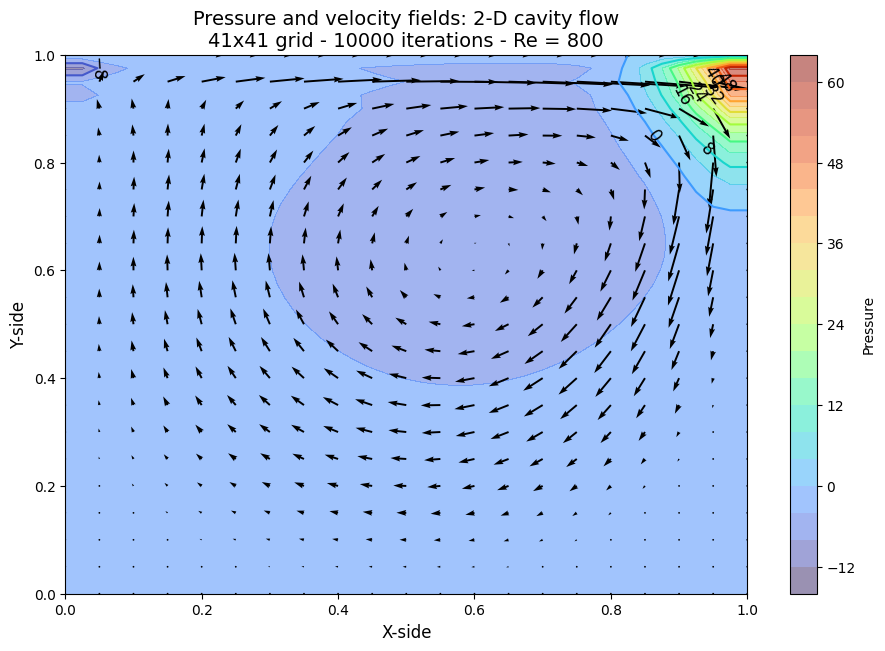

In [153]:
# If streamlines==False, an 2D arrow map will be drawn

plot_results(X, Y, u, v, p, streamlines=False, save=False)

In [ ]:
# Empty cell useful for working :)

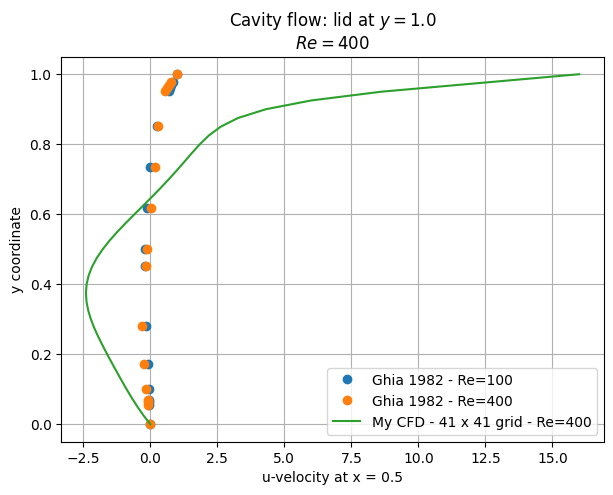

In [129]:
# Benchmarking with the data of the high fidelity simulation done by Ghia et al. in 1982

# import pandas as pd
# df = pd.read_csv("Ghia_1982.txt")
# data = df.to_numpy()
data = np.loadtxt("Ghia_1982.txt")   #Ordered as: y-coordinate, Re=100, Re=400

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.plot(data[:,1], data[:,0], 'o', label='Ghia 1982 - Re=100')
ax.plot(data[:,2], data[:,0], 'o', label='Ghia 1982 - Re=400')
ax.plot(u[:, 20], y, label=f'My CFD - 41 x 41 grid - Re={int(c*length/nu)}')
# ax.yaxis.set_inverted(True)
ax.set_xlabel("u-velocity at x = 0.5")
ax.set_ylabel("y coordinate")
ax.set_title(f"Cavity flow: lid at $y = 1.0$\n$Re = {int(c*length/nu)}$")
ax.legend()
ax.grid()
plt.show()

# Step 13.5: 2-D Cavity Flow with Chorin's projection method

It's a future project, which may never be done...